In [1]:
import pandas as pd
import sklearn as sk 
import matplotlib.pyplot as plt

In [3]:
games = pd.read_csv('./datasets/avaliação1/games_dataset.csv')
games_json = pd.read_json('./datasets/avaliação1/games_metadata.json',lines=True)

In [4]:
datasetsOriginal = {
    "games": games.copy()
}

In [5]:
games.head()

,app_id,user_reviews,price_final,positive_reviews,negative_reviews,positive_hours,negative_hours
0,13500,1686,9.99,1426,260,29285.0,2694.9
1,113020,6943,14.99,6308,635,139308.5,2421.0
2,226560,877,14.99,549,328,6687.3,2763.8
3,249050,4850,11.99,4295,555,189620.1,7395.1
4,250180,5385,7.99,4814,571,51532.2,3085.6


In [6]:
games.isnull().sum()

app_id              0
user_reviews        0
price_final         0
positive_reviews    0
negative_reviews    0
positive_hours      0
negative_hours      0
dtype: int64

In [7]:
games.shape

(37610, 7)

In [8]:
def plotar_boxplot(list_columns,variables_names,ylim):
    window = plt.figure(figsize=(10,5))
    grafico = window.add_axes([0,0,1,1])
    grafico.boxplot(list_columns)
    grafico.set_ylim(0, ylim)
    grafico.set_xticklabels(list_names)

    plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

def plotarGraficoFO(database: pd.DataFrame):
    wcss = [] 
    sil_scores = [] 
    ch_scores = [] 

    # 1. Removendo a primeira coluna (app_id) e tratando o tamanho do sample
    dataset = database.drop(database.columns[0], axis=1, errors='ignore')
    
    # Garante que o sample não seja maior que o dataset disponível
    n_samples = min(len(dataset), 50000)
    dataset = dataset.sample(n=n_samples, random_state=42)

    # 2. Normalizando os dados (Essencial para K-Means)
    scaler = StandardScaler()
    dataset_normalized = scaler.fit_transform(dataset)

    # 3. Laço para testar de 2 a 10 clusters
    for i in range(2, 11):
        kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
        cl = kmeans.fit_predict(dataset_normalized)
        
        # Armazenando métricas
        sil_scores.append(silhouette_score(dataset_normalized, cl))
        ch_scores.append(calinski_harabasz_score(dataset_normalized, cl))
        wcss.append(kmeans.inertia_)

    # 4. Plotagem dos Gráficos
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Gráfico 1: Método do Cotovelo
    axes[0].plot(range(2, 11), wcss, marker='o', color='blue')
    axes[0].set_title('Método do Cotovelo (WCSS)')
    axes[0].set_xlabel('Número de clusters (k)')
    axes[0].set_ylabel('WCSS')

    # Gráfico 2: Silhouette Score (Quanto mais próximo de 1, melhor)
    axes[1].plot(range(2, 11), sil_scores, marker='o', color='green')
    axes[1].set_title('Silhouette Score')
    axes[1].set_xlabel('Número de clusters (k)')
    axes[1].set_ylabel('Silhouette')

    # Gráfico 3: Calinski-Harabasz (Quanto maior, melhor)
    axes[2].plot(range(2, 11), ch_scores, marker='o', color='red')
    axes[2].set_title('Calinski-Harabasz Index')
    axes[2].set_xlabel('Número de clusters (k)')
    axes[2].set_ylabel('CH Score')

    plt.tight_layout()
    plt.show()

In [10]:
outliers_list = []  # Lista para armazenar as informações dos outliers

In [11]:
def clip_outliers(
    df, 
    cols, 
    name,
    lower_q=0.01, 
    upper_q=0.99
):
    df = df.copy()

    for col in cols:
        q_low = df[col].quantile(lower_q)
        q_high = df[col].quantile(upper_q)

        # Identificar quem são os outliers antes do clip
        # Filtramos o DataFrame para encontrar valores abaixo do mínimo ou acima do máximo
        condicao_outlier = (df[col] < q_low) | (df[col] > q_high)
        dados_outliers = df[condicao_outlier][col]

        # Adicionar cada outlier encontrado na lista
        for idx, valor in dados_outliers.items():
            outliers_list.append({
                'coluna': col,
                'indice_original': idx,
                'valor_outlier': valor,
                "name": name
            })

        # Agora aplicamos o clip para limitar os valores
        df[col] = df[col].clip(q_low, q_high)

    return df

# Exemplo de como usar:
# df_limpo, lista_de_outliers = clip_outliers(database, ['coluna1', 'coluna2'])

In [12]:
import pandas as pd

def readicionarOutliers(database: pd.DataFrame,databaseReference: pd.DataFrame, datasetName,kmeans):
    target_name = datasetName
    df_outliers_filtrados = pd.DataFrame([o for o in outliers_list if o['name'] == target_name])

    indices_outliers = df_outliers_filtrados['indice_original'].unique()


    dados_outliers_originais = databaseReference.loc[indices_outliers]

    dados_outliers_originais = dados_outliers_originais.drop(columns= dados_outliers_originais.columns[0], errors='ignore')

    outliers_normalizados = scaler.transform(dados_outliers_originais)

    outliers_labels = kmeans.predict(outliers_normalizados)

    df_reinsercao = dados_outliers_originais.copy()
    df_reinsercao['cluster_kmeans'] = outliers_labels

    database.update(df_reinsercao)

    return database

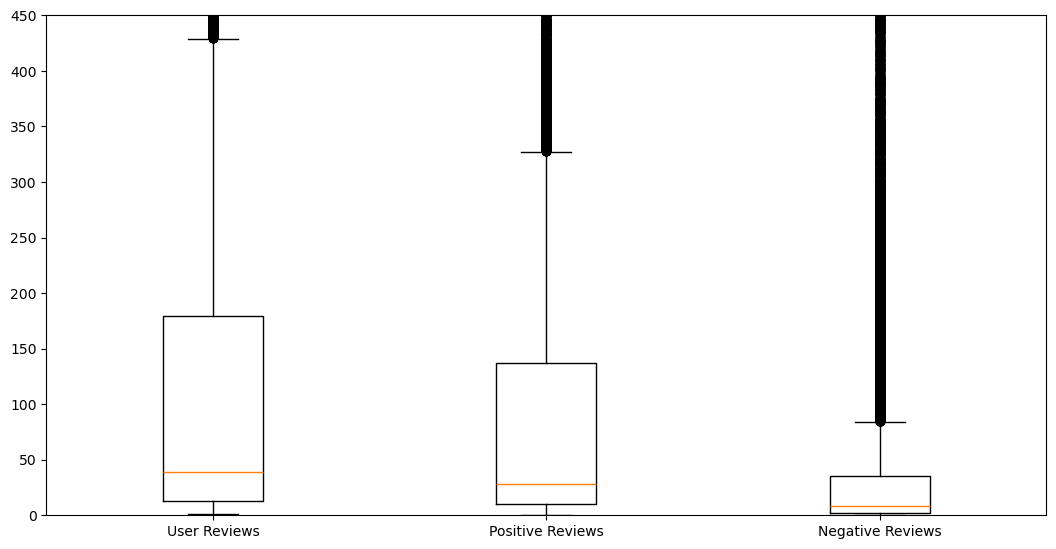

In [12]:
list_reviews = [games['user_reviews'], games['positive_reviews'], games['negative_reviews']]
list_names = ['User Reviews', 'Positive Reviews', 'Negative Reviews']
plotar_boxplot(list_reviews,list_names,450)

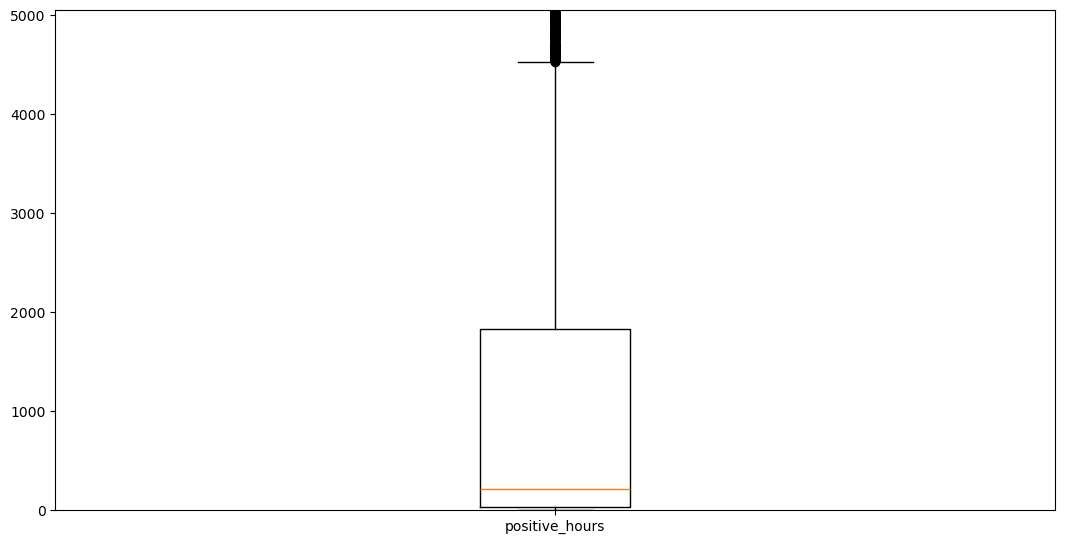

In [13]:
list_phours = [games['positive_hours']]
list_names = ['positive_hours']
plotar_boxplot(list_phours,list_names,5050)

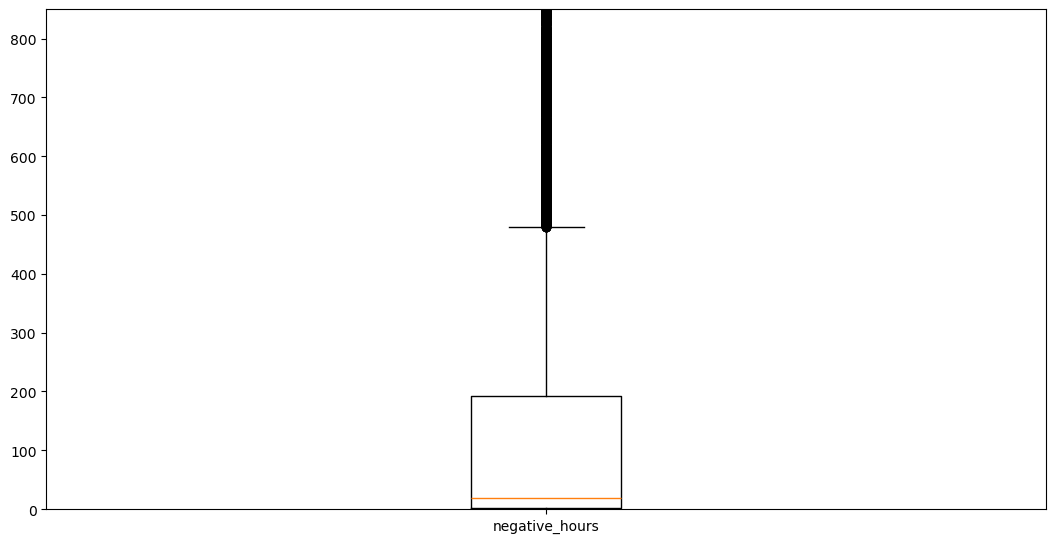

In [14]:
list_nhours = [games['negative_hours']]
list_names = ['negative_hours']
plotar_boxplot(list_nhours,list_names,850)

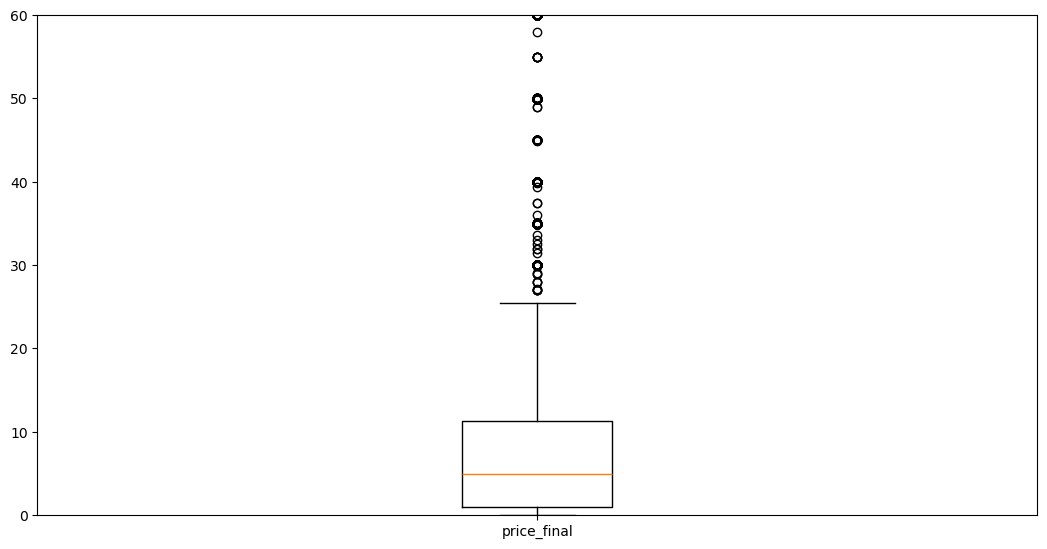

In [15]:
list_price = [games['price_final']]
list_names = ['price_final']
plotar_boxplot(list_price,list_names,60)

In [13]:
games_outliers = games.copy()
games_outliers = clip_outliers(games, ["user_reviews","price_final","positive_reviews","negative_reviews","positive_hours","negative_hours"], "games")

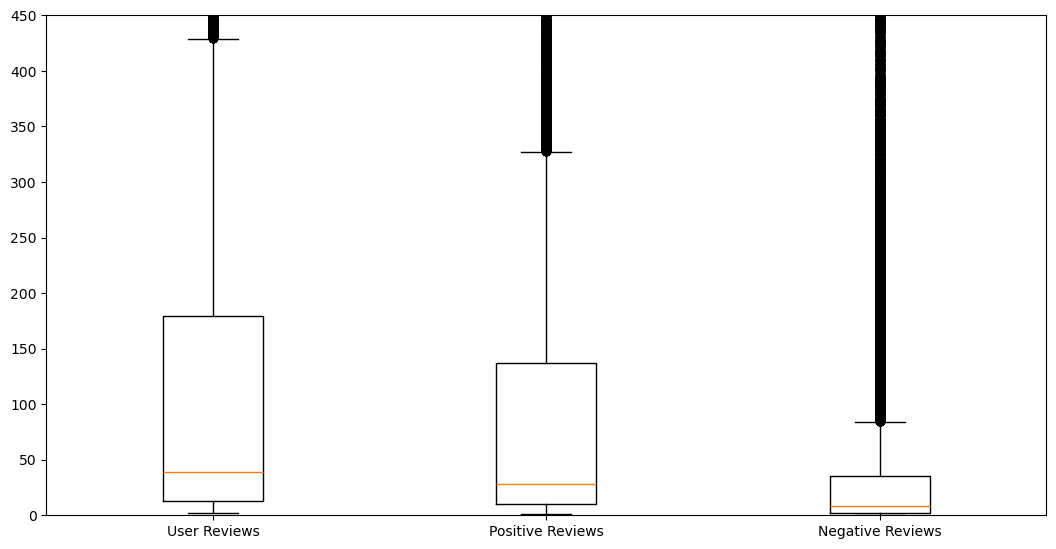

In [17]:
list_reviews = [games_outliers['user_reviews'], games_outliers['positive_reviews'], games_outliers['negative_reviews']]
list_names = ['User Reviews', 'Positive Reviews', 'Negative Reviews']
plotar_boxplot(list_reviews,list_names,450)

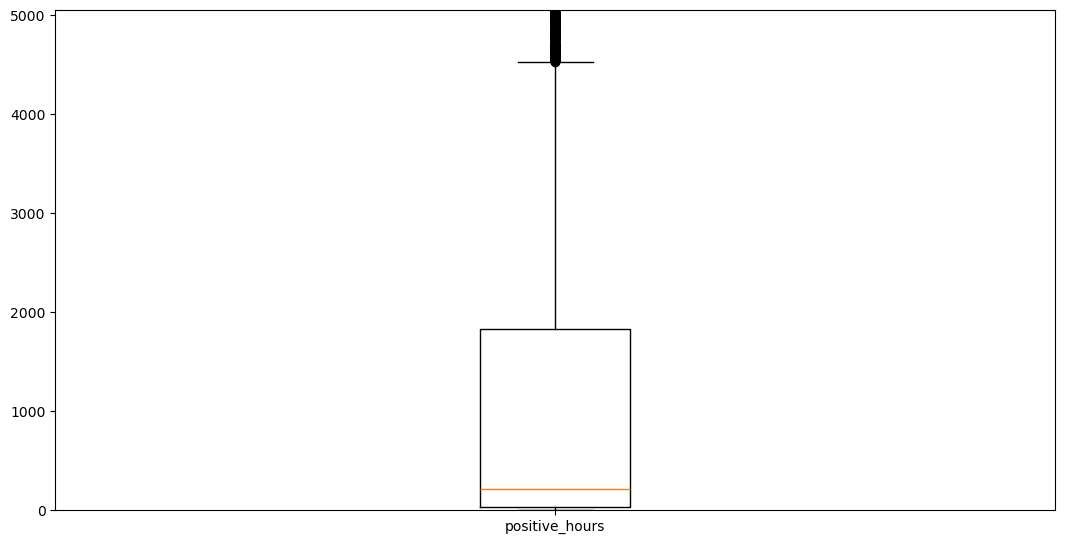

In [18]:
list_phours = [games_outliers['positive_hours']]
list_names = ['positive_hours']
plotar_boxplot(list_phours,list_names,5050)

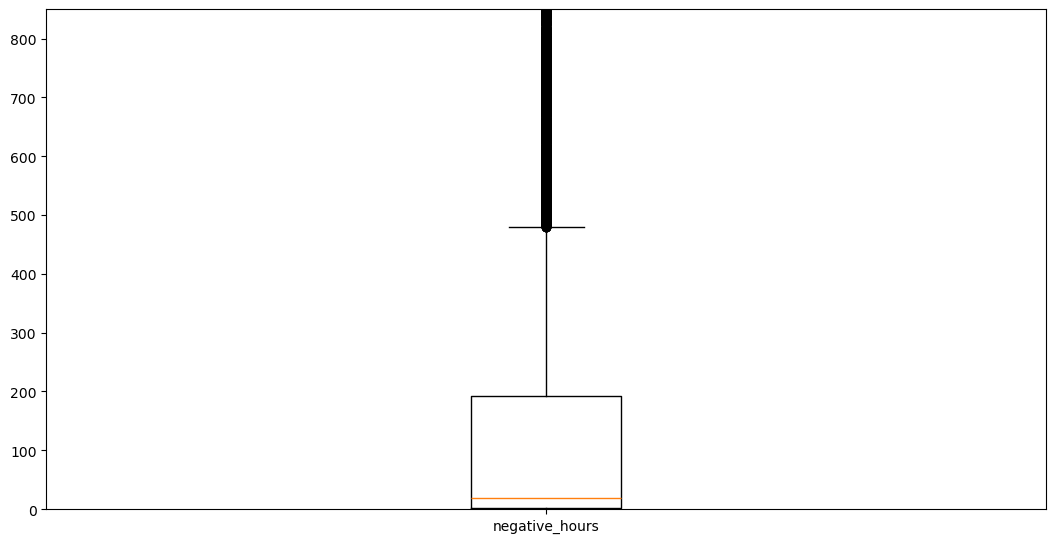

In [19]:
list_nhours = [games_outliers['negative_hours']]
list_names = ['negative_hours']
plotar_boxplot(list_nhours,list_names,850)

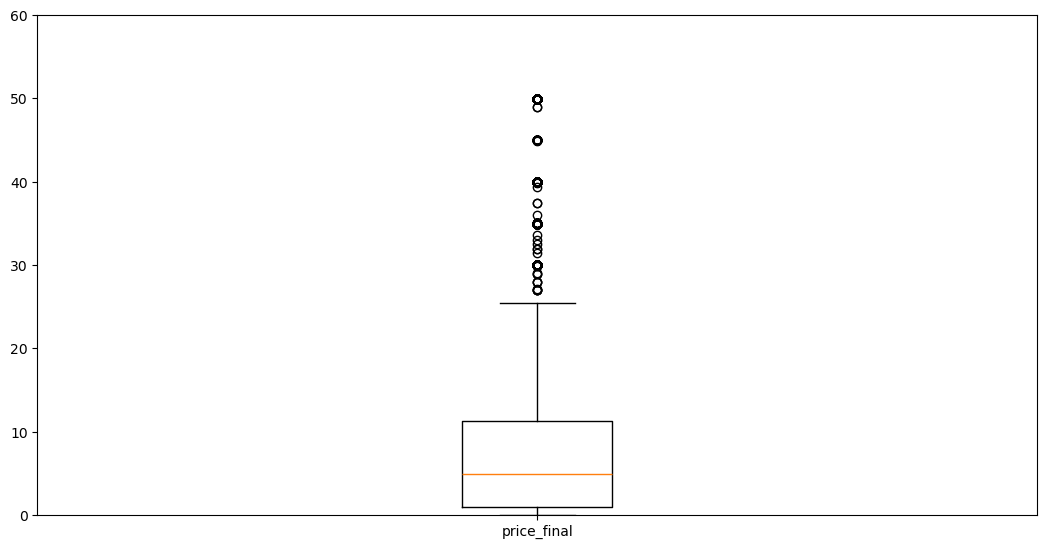

In [20]:
list_price = [games_outliers['price_final']]
list_names = ['price_final']
plotar_boxplot(list_price,list_names,60)

C:\Users\luism\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\luism\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\luism\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\luism\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^

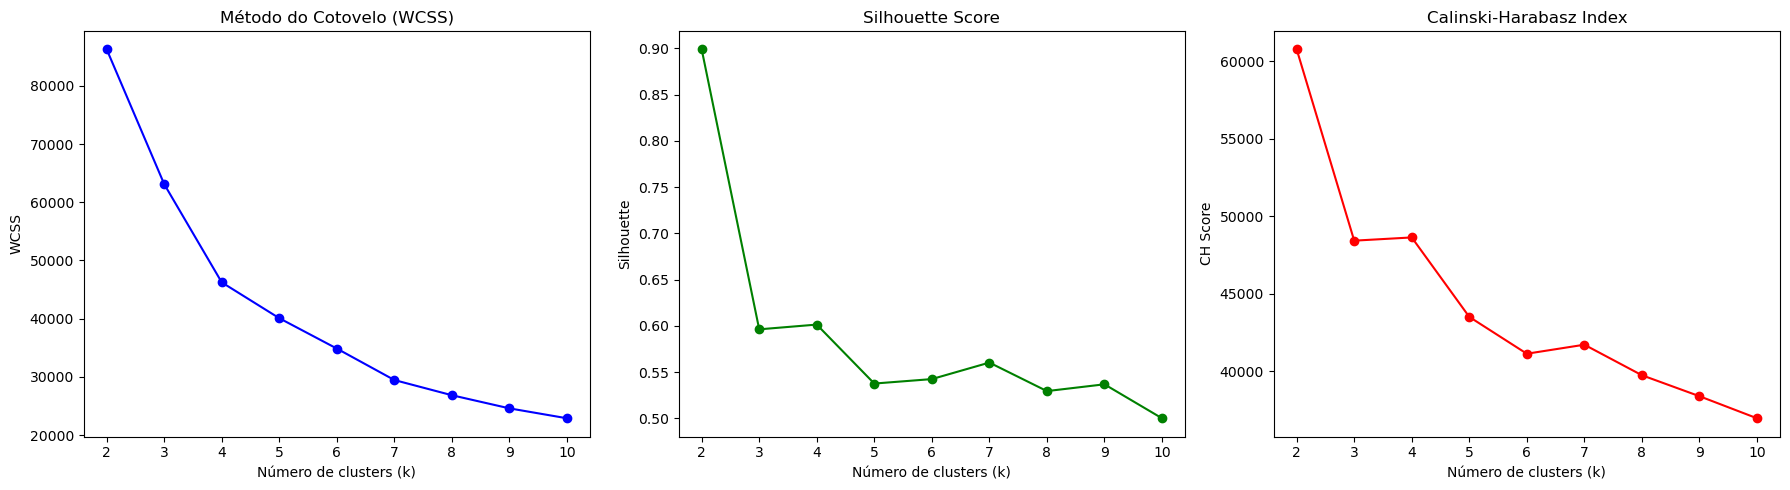

In [21]:
plotarGraficoFO(games_outliers)

In [14]:
X = games_outliers.drop(columns = ['app_id'], errors= 'ignore')

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar K-Means com k=6
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Adicionar os rótulos dos clusters ao DataFrame original
games_outliers['cluster_kmeans'] = kmeans.labels_

full_games = readicionarOutliers(games_outliers,datasetsOriginal.get("games"),"games",kmeans)

# Exibir a contagem de jogos por cluster
print(full_games['cluster_kmeans'].value_counts())

# Visualizar o centro (média) de cada cluster
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                               columns=X.columns)
print("\nCentros dos Clusters:")
print(cluster_centers)

cluster_kmeans
0    28738
3     7514
2      792
1      566
Name: count, dtype: int64

Centros dos Clusters:
   user_reviews  price_final  positive_reviews  negative_reviews  \
0    179.909319     4.203600        149.677987         30.228722   
1  21160.068640    20.493716      17817.063448       2366.048429   
2   8659.605749    16.474060       7411.870359       1131.962874   
3    485.779108    21.848892        412.188822         73.586959   

   positive_hours  negative_hours  
0    3.343002e+03      333.305265  
1    1.283515e+06    93855.083213  
2    3.476725e+05    31224.571083  
3    1.455419e+04     1181.087572  


C:\Users\luism\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\luism\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\luism\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\luism\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^

In [15]:
full_dataset_games = pd.merge(full_games, games_json, on='app_id', how='left')

In [16]:
full_dataset_games['tags'].head()

0    [Action, Adventure, Parkour, Third Person, Gre...
1    [Co-op, Stealth, Indie, Heist, Local Co-Op, St...
2    [Zombies, Adventure, Survival, Action, Third P...
3    [Roguelike, Strategy, Tower Defense, Pixel Gra...
4    [Arcade, Classic, Action, Co-op, Side Scroller...
Name: tags, dtype: object

[('Indie', 23480), ('Singleplayer', 19538), ('Adventure', 16318), ('Action', 16190), ('Casual', 15300), ('2D', 10177), ('Simulation', 8625), ('Strategy', 8280), ('Atmospheric', 7468), ('RPG', 7452)]


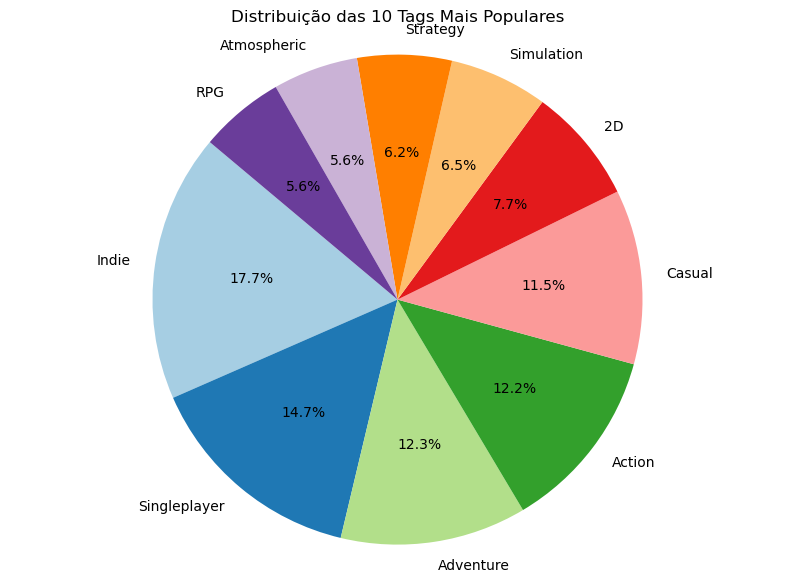

In [25]:
from collections import Counter

tag_list = []
for tags in full_dataset_games['tags']:
    for tag in tags:
        tag_list.append(tag)
        
contagem = Counter(tag_list)

# Retorna uma lista de tuplas ordenada pela frequência
print(contagem.most_common(10)) # As 10 tags mais frequentes
top_10_tags = contagem.most_common(10)

# 2. Separar as tuplas em duas listas para o gráfico
nomes = [item[0] for item in top_10_tags]
valores = [item[1] for item in top_10_tags]

# 3. Criar o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    valores, 
    labels=nomes, 
    autopct='%1.1f%%', # Formata para mostrar a porcentagem com uma casa decimal
    startangle=140,    # Rotaciona o gráfico para uma melhor visualização
    colors=plt.cm.Paired.colors # Usa uma paleta de cores pré-definida e bonita
)

plt.title('Distribuição das 10 Tags Mais Populares')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo perfeito
plt.show()

[('Indie', 19319), ('Singleplayer', 14126), ('Casual', 13221), ('Adventure', 12257), ('Action', 12165), ('2D', 8217), ('Simulation', 6162), ('Strategy', 5983), ('Puzzle', 5753), ('Atmospheric', 5368)]


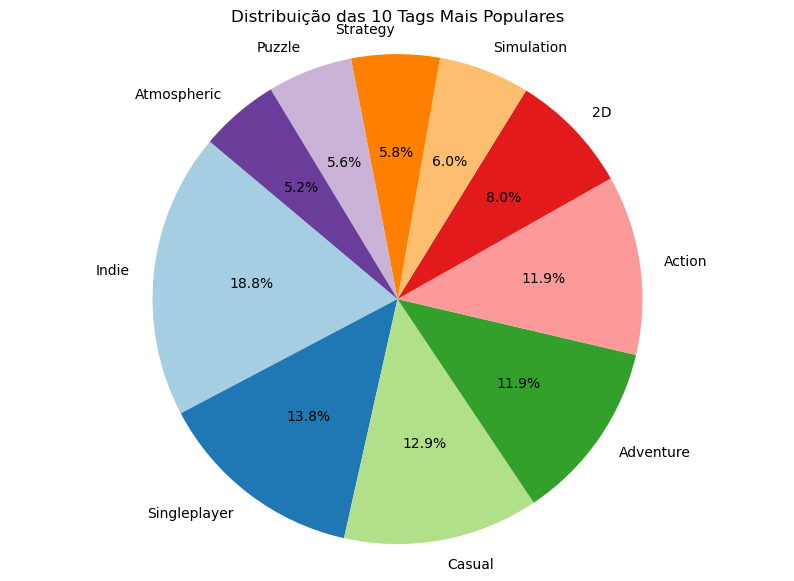

In [26]:
from collections import Counter

tag_list = []
grupo0 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 0]
for tags in grupo0['tags']:
    for tag in tags:
        tag_list.append(tag)
        
contagem = Counter(tag_list)

# Retorna uma lista de tuplas ordenada pela frequência
print(contagem.most_common(10)) # As 10 tags mais frequentes

top_10_tags = contagem.most_common(10)

# 2. Separar as tuplas em duas listas para o gráfico
nomes = [item[0] for item in top_10_tags]
valores = [item[1] for item in top_10_tags]

# 3. Criar o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    valores, 
    labels=nomes, 
    autopct='%1.1f%%', # Formata para mostrar a porcentagem com uma casa decimal
    startangle=140,    # Rotaciona o gráfico para uma melhor visualização
    colors=plt.cm.Paired.colors # Usa uma paleta de cores pré-definida e bonita
)

plt.title('Distribuição das 10 Tags Mais Populares')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo perfeito
plt.show()

[('Action', 183), ('Singleplayer', 178), ('Multiplayer', 175), ('Adventure', 152), ('Open World', 116), ('Co-op', 111), ('Atmospheric', 100), ('Shooter', 97), ('Indie', 93), ('Strategy', 83)]


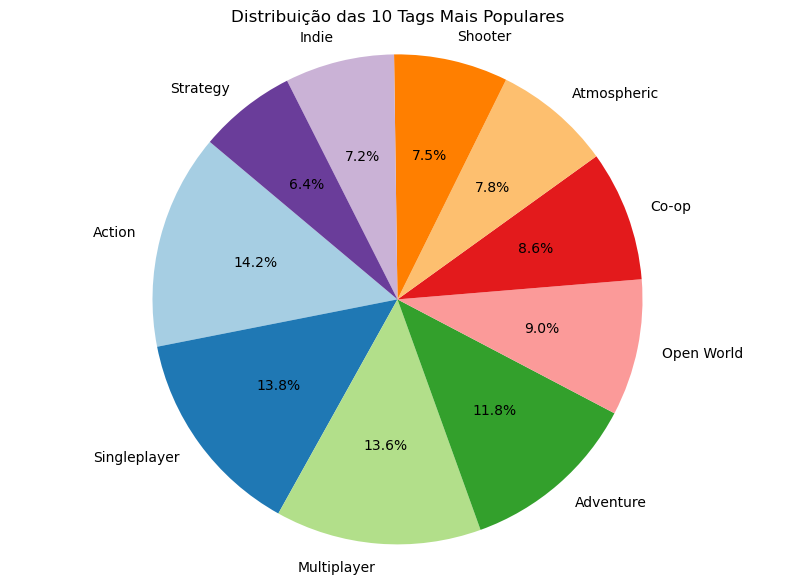

In [27]:
from collections import Counter

tag_list = []
grupo1 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 1]
for tags in grupo1['tags']:
    for tag in tags:
        tag_list.append(tag)
        
contagem = Counter(tag_list)

# Retorna uma lista de tuplas ordenada pela frequência
print(contagem.most_common(10)) # As 10 tags mais frequentes
top_10_tags = contagem.most_common(10)

# 2. Separar as tuplas em duas listas para o gráfico
nomes = [item[0] for item in top_10_tags]
valores = [item[1] for item in top_10_tags]

# 3. Criar o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    valores, 
    labels=nomes, 
    autopct='%1.1f%%', # Formata para mostrar a porcentagem com uma casa decimal
    startangle=140,    # Rotaciona o gráfico para uma melhor visualização
    colors=plt.cm.Paired.colors # Usa uma paleta de cores pré-definida e bonita
)

plt.title('Distribuição das 10 Tags Mais Populares')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo perfeito
plt.show()

[('Singleplayer', 542), ('Action', 490), ('Adventure', 412), ('Multiplayer', 385), ('Atmospheric', 286), ('Indie', 273), ('Open World', 255), ('Co-op', 251), ('Great Soundtrack', 237), ('RPG', 231)]


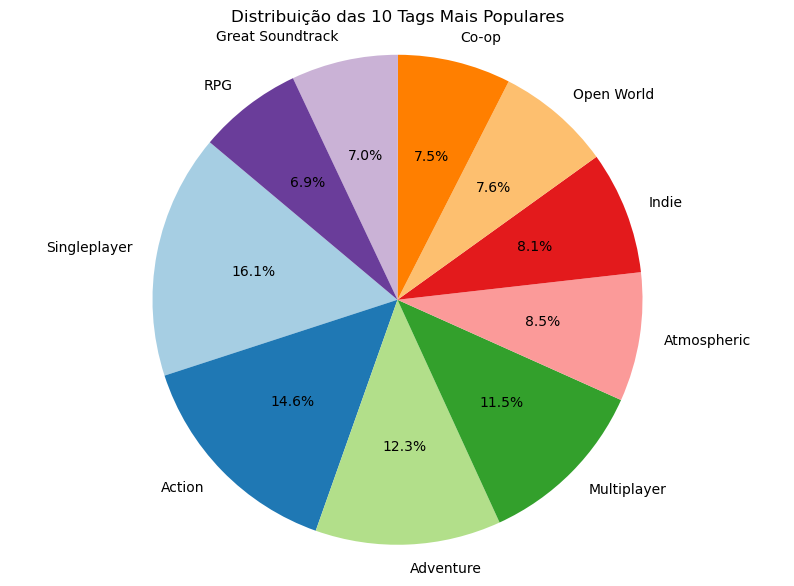

In [28]:
from collections import Counter

tag_list = []
grupo2 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 2]
for tags in grupo2['tags']:
    for tag in tags:
        tag_list.append(tag)
        
contagem = Counter(tag_list)

# Retorna uma lista de tuplas ordenada pela frequência
print(contagem.most_common(10)) # As 10 tags mais frequentes
top_10_tags = contagem.most_common(10)

# 2. Separar as tuplas em duas listas para o gráfico
nomes = [item[0] for item in top_10_tags]
valores = [item[1] for item in top_10_tags]

# 3. Criar o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    valores, 
    labels=nomes, 
    autopct='%1.1f%%', # Formata para mostrar a porcentagem com uma casa decimal
    startangle=140,    # Rotaciona o gráfico para uma melhor visualização
    colors=plt.cm.Paired.colors # Usa uma paleta de cores pré-definida e bonita
)

plt.title('Distribuição das 10 Tags Mais Populares')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo perfeito
plt.show()

[('Singleplayer', 4692), ('Indie', 3795), ('Adventure', 3497), ('Action', 3352), ('Simulation', 2230), ('Strategy', 2018), ('RPG', 1962), ('Story Rich', 1900), ('Casual', 1881), ('2D', 1802)]


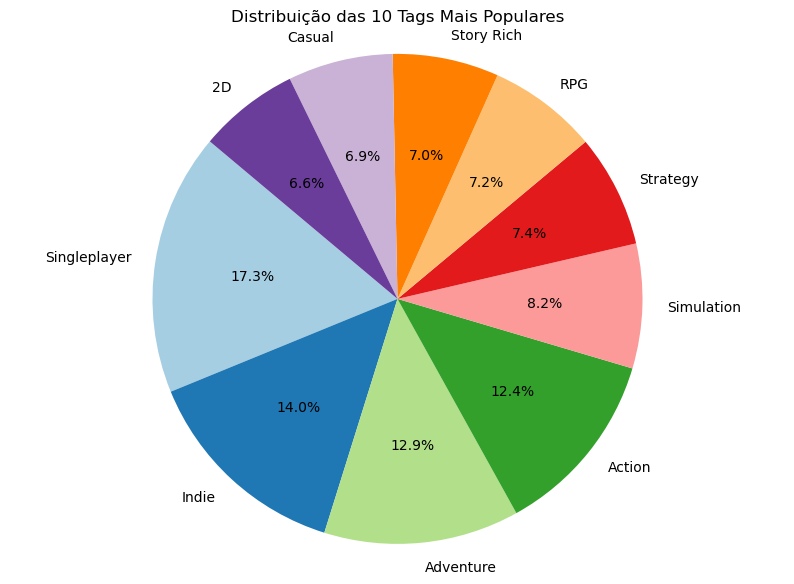

In [29]:
from collections import Counter

tag_list = []
grupo3 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 3]
for tags in grupo3['tags']:
    for tag in tags:
        tag_list.append(tag)
        
contagem = Counter(tag_list)

# Retorna uma lista de tuplas ordenada pela frequência
print(contagem.most_common(10)) # As 10 tags mais frequentes
top_10_tags = contagem.most_common(10)

# 2. Separar as tuplas em duas listas para o gráfico
nomes = [item[0] for item in top_10_tags]
valores = [item[1] for item in top_10_tags]

# 3. Criar o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    valores, 
    labels=nomes, 
    autopct='%1.1f%%', # Formata para mostrar a porcentagem com uma casa decimal
    startangle=140,    # Rotaciona o gráfico para uma melhor visualização
    colors=plt.cm.Paired.colors # Usa uma paleta de cores pré-definida e bonita
)

plt.title('Distribuição das 10 Tags Mais Populares')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo perfeito
plt.show()

## Avaliação dos 20 jogos mais famosos em cada cluster

In [22]:
# Exibir a contagem de jogos por cluster
print(full_games['cluster_kmeans'].value_counts())

# Visualizar o centro (média) de cada cluster
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                               columns=X.columns)
print("\nCentros dos Clusters:")
print(cluster_centers)

cluster_kmeans
0    28738
3     7514
2      792
1      566
Name: count, dtype: int64

Centros dos Clusters:
   user_reviews  price_final  positive_reviews  negative_reviews  \
0    179.909319     4.203600        149.677987         30.228722   
1  21160.068640    20.493716      17817.063448       2366.048429   
2   8659.605749    16.474060       7411.870359       1131.962874   
3    485.779108    21.848892        412.188822         73.586959   

   positive_hours  negative_hours  
0    3.343002e+03      333.305265  
1    1.283515e+06    93855.083213  
2    3.476725e+05    31224.571083  
3    1.455419e+04     1181.087572  


In [17]:
games_names = pd.read_csv('./games.csv')
games_names = games_names[['app_id','title']]

In [18]:
full_dataset_games = pd.merge(full_dataset_games, games_names, on='app_id', how='left')

In [19]:
full_dataset_games.head()

,app_id,user_reviews,price_final,positive_reviews,negative_reviews,positive_hours,negative_hours,cluster_kmeans,description,tags,title
0,13500,1686.0,9.99,1426.0,260.0,29285.0,2694.9,0,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre...",Prince of Persia: Warrior Within™
1,113020,6943.0,14.99,6308.0,635.0,139308.5,2421.0,2,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St...",Monaco: What's Yours Is Mine
2,226560,877.0,14.99,549.0,328.0,6687.3,2763.8,3,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P...",Escape Dead Island
3,249050,4850.0,11.99,4295.0,555.0,189620.1,7395.1,3,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra...",Dungeon of the ENDLESS™
4,250180,5385.0,7.99,4814.0,571.0,51532.2,3085.6,0,"“METAL SLUG 3”, the masterpiece in SNK’s emble...","[Arcade, Classic, Action, Co-op, Side Scroller...",METAL SLUG 3


In [20]:
group1 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 0]
group2 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 1]
group3 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 2]
group4 = full_dataset_games[full_dataset_games['cluster_kmeans'] == 3]

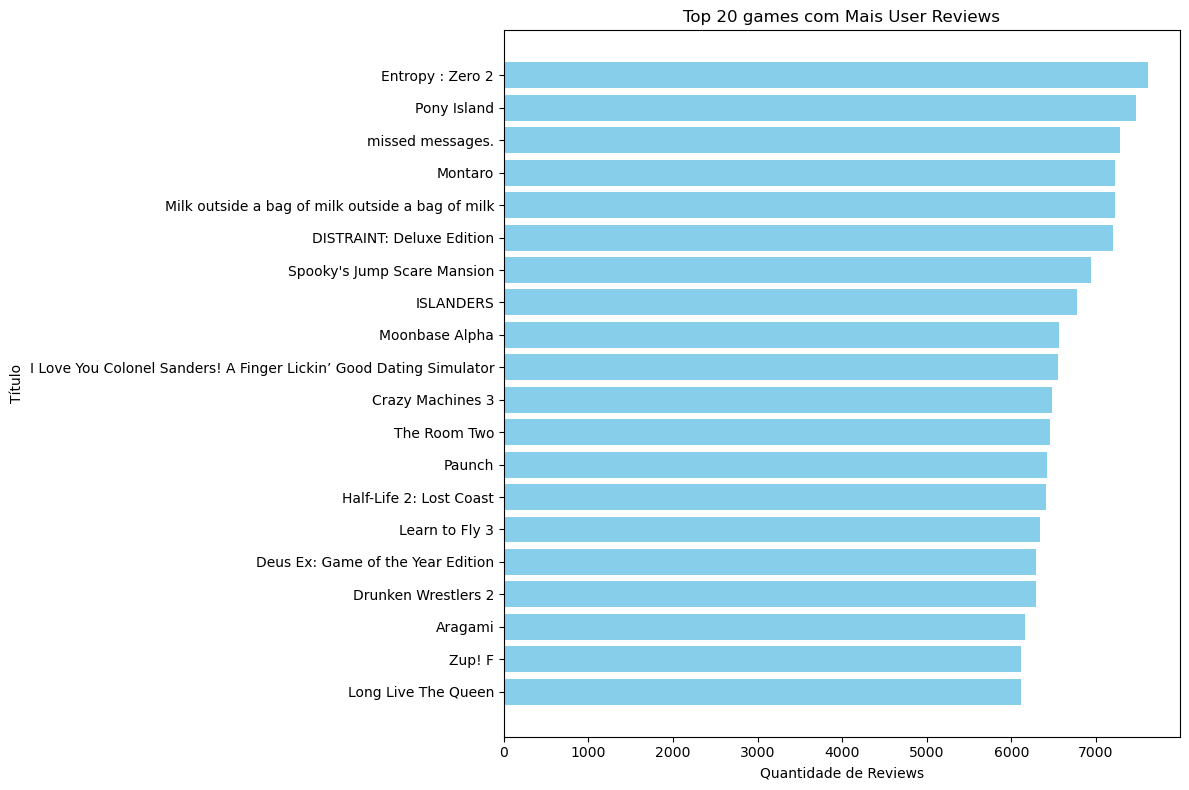

In [21]:
# Ordenar o DataFrame pela coluna 'user_reviews' de forma decrescente
# e selecionar os 20 primeiros
top_20 = group1.sort_values(by='user_reviews', ascending=False).head(20)

# Criar o gráfico
plt.figure(figsize=(12, 8))
plt.barh(top_20['title'], top_20['user_reviews'], color='skyblue')

# Adicionar labels e título
plt.xlabel('Quantidade de Reviews')
plt.ylabel('Título')
plt.title('Top 20 games com Mais User Reviews')

# Inverter a ordem do eixo Y para o maior ficar no topo
plt.gca().invert_yaxis()

# Mostrar o gráfico
plt.tight_layout()
plt.show()

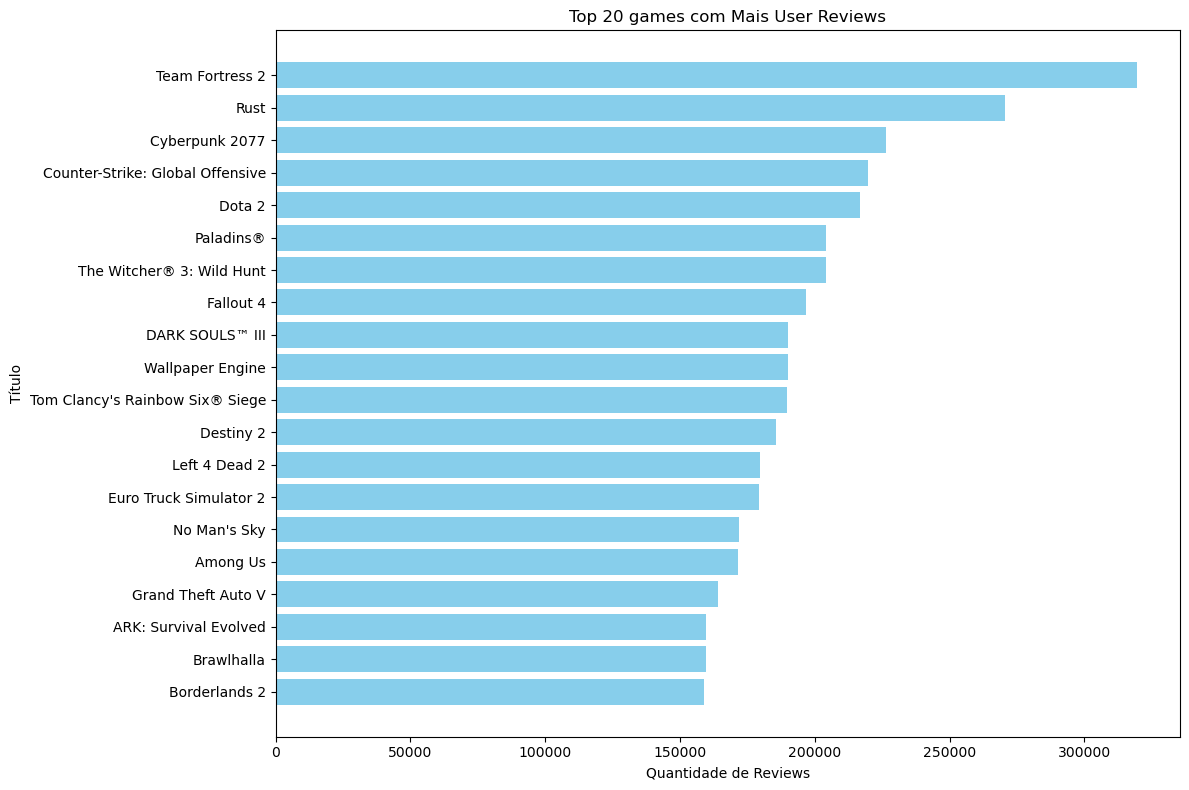

In [23]:
# Ordenar o DataFrame pela coluna 'user_reviews' de forma decrescente
# e selecionar os 20 primeiros
top_20 = group2.sort_values(by='user_reviews', ascending=False).head(20)

# Criar o gráfico
plt.figure(figsize=(12, 8))
plt.barh(top_20['title'], top_20['user_reviews'], color='skyblue')

# Adicionar labels e título
plt.xlabel('Quantidade de Reviews')
plt.ylabel('Título')
plt.title('Top 20 games com Mais User Reviews')

# Inverter a ordem do eixo Y para o maior ficar no topo
plt.gca().invert_yaxis()

# Mostrar o gráfico
plt.tight_layout()
plt.show()

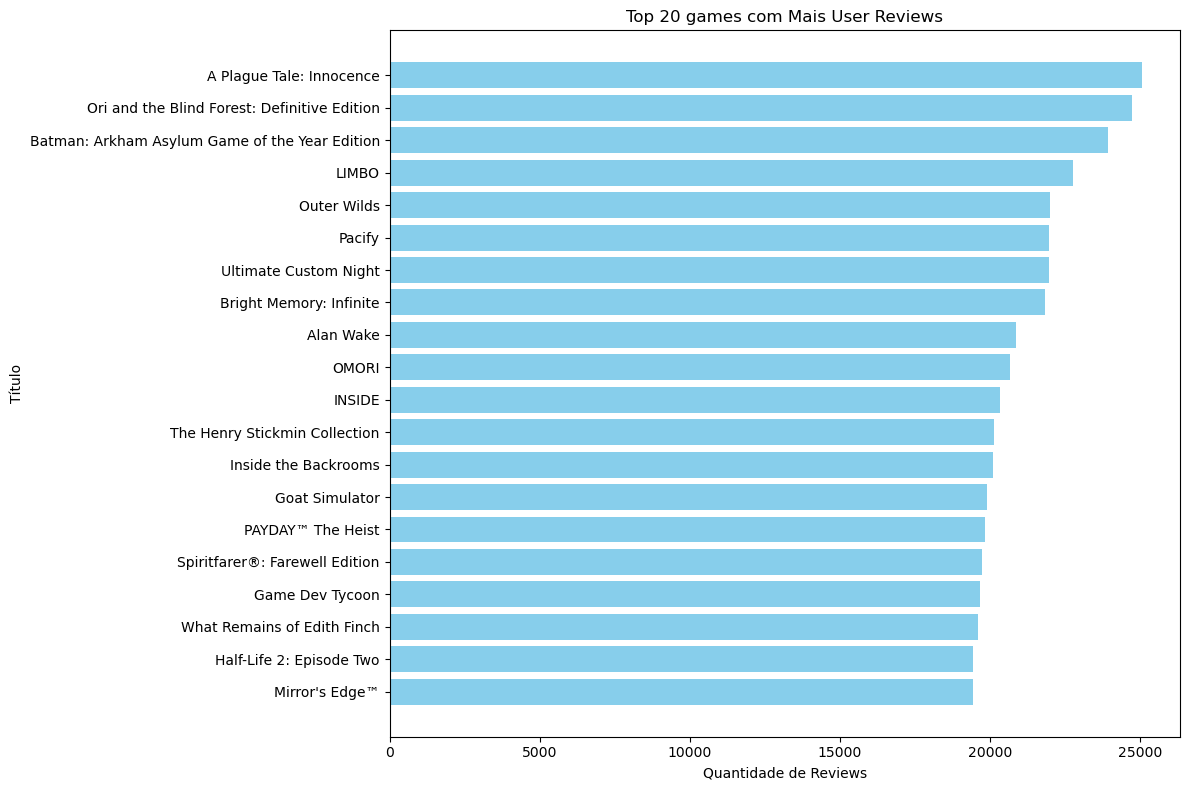

In [24]:
# Ordenar o DataFrame pela coluna 'user_reviews' de forma decrescente
# e selecionar os 20 primeiros
top_20 = group3.sort_values(by='user_reviews', ascending=False).head(20)

# Criar o gráfico
plt.figure(figsize=(12, 8))
plt.barh(top_20['title'], top_20['user_reviews'], color='skyblue')

# Adicionar labels e título
plt.xlabel('Quantidade de Reviews')
plt.ylabel('Título')
plt.title('Top 20 games com Mais User Reviews')

# Inverter a ordem do eixo Y para o maior ficar no topo
plt.gca().invert_yaxis()

# Mostrar o gráfico
plt.tight_layout()
plt.show()

C:\Users\luism\AppData\Local\Temp\ipykernel_34140\4163227056.py:18: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luism\AppData\Local\Temp\ipykernel_34140\4163227056.py:18: UserWarning: Glyph 30333 (\N{CJK UNIFIED IDEOGRAPH-767D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luism\AppData\Local\Temp\ipykernel_34140\4163227056.py:18: UserWarning: Glyph 20820 (\N{CJK UNIFIED IDEOGRAPH-5154}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luism\AppData\Local\Temp\ipykernel_34140\4163227056.py:18: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luism\AppData\Local\Temp\ipykernel_34140\4163227056.py:18: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luism\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2

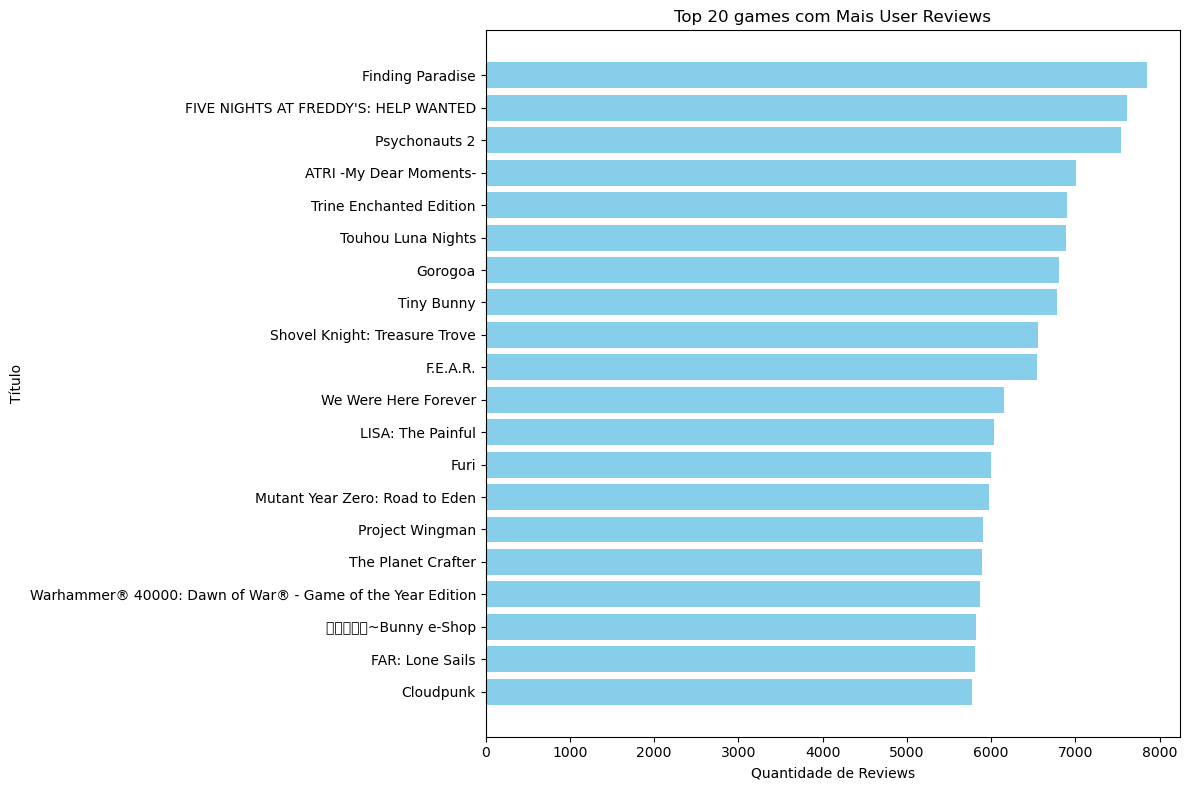

In [25]:
# Ordenar o DataFrame pela coluna 'user_reviews' de forma decrescente
# e selecionar os 20 primeiros
top_20 = group4.sort_values(by='user_reviews', ascending=False).head(20)

# Criar o gráfico
plt.figure(figsize=(12, 8))
plt.barh(top_20['title'], top_20['user_reviews'], color='skyblue')

# Adicionar labels e título
plt.xlabel('Quantidade de Reviews')
plt.ylabel('Título')
plt.title('Top 20 games com Mais User Reviews')

# Inverter a ordem do eixo Y para o maior ficar no topo
plt.gca().invert_yaxis()

# Mostrar o gráfico
plt.tight_layout()
plt.show()